## Conversión de Audio a Mel-Spectrogramas en GPU

Este bloque procesa todos los archivos `.wav` de la carpeta `archive` y sus subdirectorios (clases), convirtiéndolos a imágenes mel-espectrogram que se guardan en `archive_img` con la misma estructura de carpetas pero con sufijo `_img`.

In [1]:
import torch
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.io import wavfile
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Encontrar la carpeta raíz del proyecto
def find_project_root(start: Path) -> Path:
    """Busca hacia arriba la carpeta que contiene `archive` y `archive_img`."""
    for p in [start, *start.parents]:
        if (p / "archive").exists() and (p / "archive_img").exists():
            return p
    return start

base_dir = find_project_root(Path.cwd())
source_root = base_dir / "archive"
target_root = base_dir / "archive_img"

print(f"Origen: {source_root}")
print(f"Destino: {target_root}")

# Validar carpetas
if not source_root.exists() or not target_root.exists():
    raise FileNotFoundError(f"No se encontraron las carpetas esperadas")

# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}\n")

# Mel-Spectrogram en GPU
mel_transform = T.MelSpectrogram(
    sample_rate=16000, n_fft=1024, hop_length=256, n_mels=128
).to(device)

def load_wav_as_tensor(audio_path: Path):
    """Carga WAV sin dependencias problemáticas."""
    sr, data = wavfile.read(str(audio_path))
    if data.dtype.kind in {"i", "u"}:
        max_val = float(max(abs(data.min()), abs(data.max()), 1))
        data = data.astype("float32") / max_val
    else:
        data = data.astype("float32")
    if data.ndim == 1:
        data = data[None, :]
    else:
        data = data.T
    return torch.from_numpy(data), sr

def norm_to_uint8(arr):
    """Normaliza array a uint8 para guardar como imagen."""
    arr = np.clip(arr, 0, None)
    arr = (arr / (arr.max() + 1e-8) * 255).astype("uint8")
    return arr

saved_count = 0
skipped_count = 0

# Solo procesar estas carpetas
COMMANDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]

for cmd in COMMANDS:
    class_dir = source_root / cmd
    if not class_dir.is_dir():
        print(f"  ⚠ No encontrada: {class_dir}")
        continue
    
    target_class_dir = target_root / f"{cmd}_img"
    target_class_dir.mkdir(parents=True, exist_ok=True)
    
    wav_files = list(class_dir.glob("*.wav"))
    if len(wav_files) > 0:
        print(f"{class_dir.name}: {len(wav_files)} archivos")
    
    for audio_path in wav_files:
        try:
            waveform, sr = load_wav_as_tensor(audio_path)
            if waveform.size(0) > 1:
                waveform = waveform.mean(dim=0, keepdim=True)
            
            waveform = waveform.to(device)
            if sr != 16000:
                resampler = T.Resample(orig_freq=sr, new_freq=16000).to(device)
                waveform = resampler(waveform)
            
            mel = mel_transform(waveform)
            mel_db = torch.log10(mel + 1e-9).squeeze(0).detach().cpu().numpy()
            mel_img = norm_to_uint8(mel_db)
            
            out_path = target_class_dir / (audio_path.stem + ".png")
            plt.imsave(str(out_path), mel_img, cmap="magma")
            
            saved_count += 1
        except Exception as e:
            skipped_count += 1

print(f"\n{'='*50}")
print(f"Imágenes guardadas: {saved_count}")
print(f"Omitidos: {skipped_count}")
print(f"{'='*50}")

Origen: c:\AI_Proyecto1_2026\modelos\archive
Destino: c:\AI_Proyecto1_2026\modelos\archive_img
Dispositivo: cuda

yes: 4044 archivos
no: 3941 archivos
up: 3723 archivos
down: 3917 archivos
left: 3801 archivos
right: 3778 archivos
on: 3845 archivos
off: 3745 archivos
stop: 3872 archivos
go: 3880 archivos

Imágenes guardadas: 38546
Omitidos: 0


Dispositivo : cuda
AMP (bf16)  : True
cuDNN bench : True
Raíz de imágenes: C:\AI_Proyecto1_2026\modelos\archive_img
Total imágenes cargadas: 38546
Train: 26982 | Val: 5781 | Test: 5783
LeNet-5 Audio — Diagrama de capas
Input         : (B, 1, 128, 128)
Conv1 (32×5×5) + Tanh + AvgPool(2) : (B, 32, 62, 62)
Conv2 (64×5×5) + Tanh + AvgPool(2) : (B, 64, 29, 29)
Conv3 (128×5×5)+ Tanh + AvgPool(2) : (B,128, 12, 12)
Flatten                            : (B, 18432)
FC1  18432→512 + Tanh
FC2    512→128 + Tanh
FC3    128→10  (logits)

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1
------------------------------------------------------------
  Batch 0/211 — loss: 2.3053
  Batch 50/211 — loss: 2.2865
  Batch 100/211 — loss: 2.2562
  Batch 150/211 — loss: 2.0600
  Batch 200/211 — loss: 1.9683
    1 |     2.1906 |    0.1622 |   2.0515 |  0.1929 | 0.1214  Mejor modelo guardado
  Batch 0/211 — loss: 2.0212
  Batch 50/211 — loss: 2.1439
  Batch 100/211 — loss: 1.8941
  Batch 150/211 — loss: 

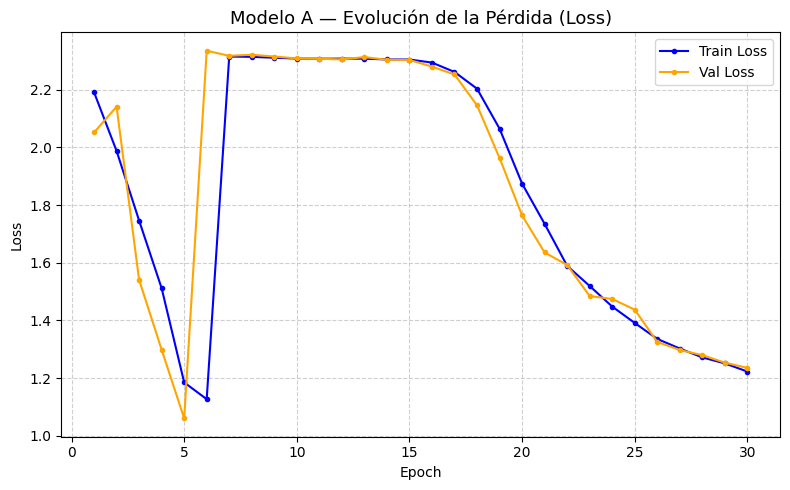

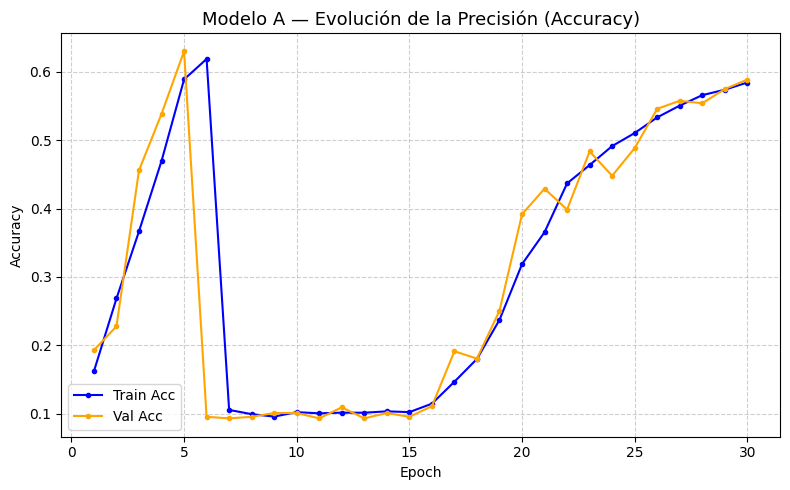

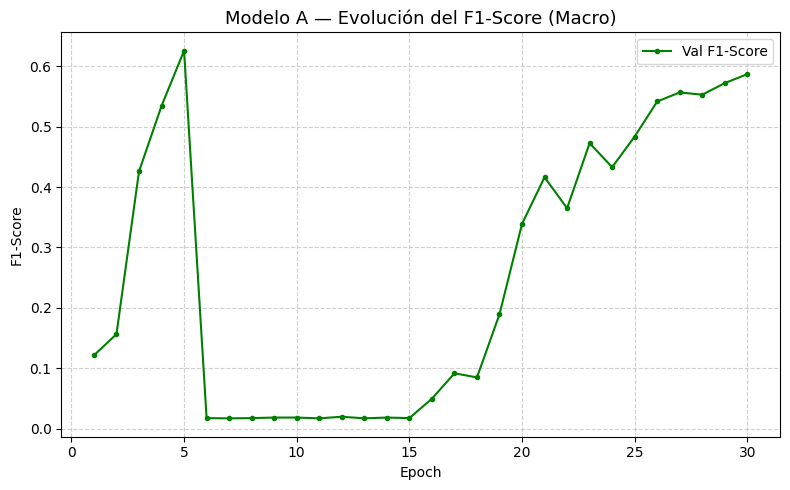


RESULTADOS EN TEST — Modelo A (datos crudos)
  Loss     : 1.0522
  Accuracy : 0.6388  (63.88 %)
  F1 Macro : 0.6344

Classification Report:
              precision    recall  f1-score   support

         yes       0.86      0.58      0.69       630
          no       0.51      0.34      0.41       569
          up       0.55      0.82      0.66       573
        down       0.54      0.77      0.64       586
        left       0.61      0.70      0.65       555
       right       0.82      0.72      0.77       576
          on       0.69      0.67      0.68       574
         off       0.70      0.48      0.57       565
        stop       0.66      0.73      0.69       558
          go       0.59      0.59      0.59       597

    accuracy                           0.64      5783
   macro avg       0.65      0.64      0.63      5783
weighted avg       0.66      0.64      0.63      5783



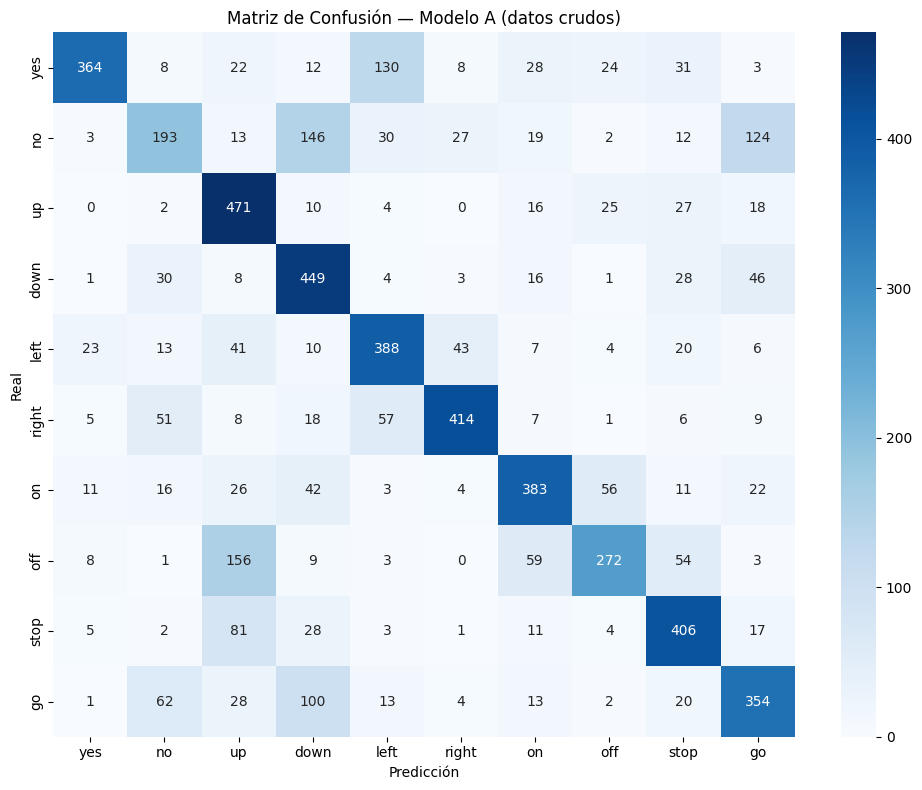


Métricas guardadas en model_a_raw_metrics.json


In [ ]:
# ============================================================
# MODELO A: LeNet-5 Clásico Adaptado para Mel-Spectrogramas
# Dataset: datos en bruto (sin augmentation)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from PIL import Image
from pathlib import Path
import numpy as np
import random
import json
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

# ──────────────────────────────────────────────
# 1. CONTROL DE ALEATORIEDAD (reproducibilidad)
# ──────────────────────────────────────────────
SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ──────────────────────────────────────────────
# 2. CONFIGURACIÓN GENERAL — VERSIÓN OPTIMIZADA RTX 50xx
# ──────────────────────────────────────────────
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

SEED = 42
COMMANDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
NUM_CLASSES = len(COMMANDS)
IMG_SIZE = 128
BATCH_SIZE = 128          # ← subido de 64: Tensor Cores prefieren batches múltiplos de 8
NUM_EPOCHS = 30
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Habilitar Tensor Cores (bfloat16 AMP — nativo en Blackwell/Ampere+) ──
USE_AMP = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

# Máxima utilización del hardware Blackwell
torch.backends.cuda.matmul.allow_tf32 = True   # TF32 en matmul (Tensor Cores)
torch.backends.cudnn.allow_tf32 = True          # TF32 en conv
torch.backends.cudnn.benchmark = True           # autotuner de kernels cuDNN

print(f"Dispositivo : {DEVICE}")
print(f"AMP (bf16)  : {USE_AMP}")
print(f"cuDNN bench : {torch.backends.cudnn.benchmark}")

# ──────────────────────────────────────────────
# 3. DATASET PERSONALIZADO (datos crudos)
# ──────────────────────────────────────────────
class MelSpectrogramDataset(Dataset):
    """
    Lee imágenes PNG de mel-espectrogramas desde archive_img/<comando>_img/*.png.
    Solo carga las clases definidas en COMMANDS.
    """
    def __init__(self, root: Path, commands: list, transform=None):
        self.samples = []   # [(path, label_idx), ...]
        self.transform = transform
        self.class_to_idx = {cmd: i for i, cmd in enumerate(commands)}

        for cmd in commands:
            class_dir = root / f"{cmd}_img"
            if not class_dir.exists():
                print(f"  ⚠ No encontrada: {class_dir}")
                continue
            files = list(class_dir.glob("*.png"))
            for f in files:
                self.samples.append((f, self.class_to_idx[cmd]))
        print(f"Total imágenes cargadas: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("L")   # escala de grises → 1 canal
        if self.transform:
            img = self.transform(img)
        return img, label


# Transformaciones mínimas (datos CRUDOS — sin augmentation)
raw_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                        # [0,255] → [0.0,1.0]
    transforms.Normalize(mean=[0.5], std=[0.5]),  # normalización estándar
])

# Ruta a las imágenes (misma lógica que la celda anterior)
base_dir = find_project_root(Path.cwd())
img_root = base_dir / "archive_img"

print(f"Raíz de imágenes: {img_root}")

# Verificar que existe
if not img_root.exists():
    raise FileNotFoundError(f"No se encontró: {img_root}")


full_dataset = MelSpectrogramDataset(img_root, COMMANDS, transform=raw_transform)

# ──────────────────────────────────────────────
# 4. SPLIT: train / val / test  (70 / 15 / 15)
# ──────────────────────────────────────────────
n_total = len(full_dataset)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds, test_ds = random_split(full_dataset, [n_train, n_val, n_test], generator=generator)

# ── DataLoaders optimizados para Windows + RTX 50xx ──
# En Windows num_workers>0 con spawn es lento; usar 4 con persistent_workers
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0,            # ← era 2
    pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True,
)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# ──────────────────────────────────────────────
# 5. ARQUITECTURA: LeNet-5 Adaptada
# ──────────────────────────────────────────────
# Modificaciones respecto al LeNet-5 original:
#   • Entrada: 1×128×128 (en lugar de 1×32×32)
#   • Más filtros en las capas conv para capturar patrones
#     espectrales más ricos (32 y 64 en vez de 6 y 16)
#   • Se mantiene la estructura clásica: Conv→Pool→Conv→Pool→FC
#   • Se reemplaza el clasificador FC final por una capa
#     convolucional 1×1 equivalente seguida de Global Average
#     Pooling para reducir parámetros (apto para móvil)
#   • Se utiliza la función Tanh clásica en cumplimiento estricto
#     con los requerimientos del proyecto.
class LeNet5Audio(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=0),
            nn.Tanh(),
            nn.AvgPool2d(2, 2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, padding=0),
            nn.Tanh(),
            nn.AvgPool2d(2, 2),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=5, padding=0),
            nn.Tanh(),
            nn.AvgPool2d(2, 2),
        )
        
        # Reemplazo de FC por Global Average Pooling + Conv 1x1
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Conv2d(128, 512, kernel_size=1),
            nn.Tanh(),
            nn.Conv2d(512, 128, kernel_size=1),
            nn.Tanh(),
            nn.Conv2d(128, num_classes, kernel_size=1),
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        
        # Pasa por el pooling global y las convoluciones 1x1
        x = self.global_pool(x)
        x = self.classifier(x)
        
        # Aplanar la salida final de (B, 10, 1, 1) a (B, 10) para el CrossEntropyLoss
        x = x.view(x.size(0), -1)
        return x

# ──────────────────────────────────────────────
# 6. DIAGRAMA DE ARQUITECTURA
# ──────────────────────────────────────────────
arch_lines = [
    "LeNet-5 Audio — Diagrama de capas",
    "="*55,
    f"Input         : (B, 1, {IMG_SIZE}, {IMG_SIZE})",
    "Conv1 (32×5×5) + Tanh + AvgPool(2) : (B, 32, 62, 62)",
    "Conv2 (64×5×5) + Tanh + AvgPool(2) : (B, 64, 29, 29)",
    "Conv3 (128×5×5)+ Tanh + AvgPool(2) : (B,128, 12, 12)",
    "Flatten                            : (B, 18432)",
    "FC1  18432→512 + Tanh",
    "FC2    512→128 + Tanh",
    f"FC3    128→{NUM_CLASSES}  (logits)",
    "="*55,
]
print("\n".join(arch_lines))
model_a = LeNet5Audio(num_classes=NUM_CLASSES).to(DEVICE)
# ──────────────────────────────────────────────
# 7. FUNCIÓN DE PÉRDIDA Y OPTIMIZADOR
# ──────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_a.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                  factor=0.5, patience=3)

# ──────────────────────────────────────────────
# 8. RUTINAS CON AMP (Automatic Mixed Precision)
# ──────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device, scaler, use_amp):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for i, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
            logits = model(imgs)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

        # ← Print cada 50 batches para ver progreso
        if i % 50 == 0:
            print(f"  Batch {i}/{len(loader)} — loss: {loss.item():.4f}", flush=True)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device, use_amp):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
                logits = model(imgs)
                loss = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, accuracy, f1, all_preds, all_labels

# ──────────────────────────────────────────────
# 9. LOOP DE ENTRENAMIENTO COMPLETO - pasar scaler y use_amp
# ──────────────────────────────────────────────
epoch_start = time.time()
history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [], "val_f1": []
}

best_val_acc = 0.0
best_model_path = base_dir / "best_model_a_raw.pth"

print(f"\n{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | "
      f"{'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>6}")
print("-" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    set_seed(SEED + epoch)
    tr_loss, tr_acc = train_one_epoch(model_a, train_loader, criterion,
                                      optimizer, DEVICE, scaler, USE_AMP)
    vl_loss, vl_acc, vl_f1, _, _ = evaluate(model_a, val_loader, criterion,
                                             DEVICE, USE_AMP)
    scheduler.step(vl_acc)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)
    history["val_f1"].append(vl_f1)

    # Guardar mejor modelo
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model_a.state_dict(), best_model_path)
        star = "Mejor modelo guardado"
    else:
        star = ""

    print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | "
          f"{vl_loss:>8.4f} | {vl_acc:>7.4f} | {vl_f1:>6.4f}  {star}")

epoch_time = time.time() - epoch_start
remaining = epoch_time * (NUM_EPOCHS - epoch)
print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | "
      f"{vl_loss:>8.4f} | {vl_acc:>7.4f} | {vl_f1:>6.4f} | "
      f"{epoch_time:>5.1f}s | ETA: {remaining/60:.1f}min  {star}")
epoch_start = time.time()

# ──────────────────────────────────────────────
# 10. CURVAS DE ENTRENAMIENTO
# ──────────────────────────────────────────────
epochs_range = range(1, NUM_EPOCHS + 1)

# --- 1. Gráfica de Pérdida (Loss) ---
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss", color='blue', marker='o', markersize=3)
plt.plot(epochs_range, history["val_loss"], label="Val Loss", color='orange', marker='o', markersize=3)
plt.title("Modelo A — Evolución de la Pérdida (Loss)", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(base_dir / "Grafica_Loss_Modelo_A_raw.png", dpi=150)
plt.show()

# --- 2. Gráfica de Precisión (Accuracy) ---
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], label="Train Acc", color='blue', marker='o', markersize=3)
plt.plot(epochs_range, history["val_acc"], label="Val Acc", color='orange', marker='o', markersize=3)
plt.title("Modelo A — Evolución de la Precisión (Accuracy)", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(base_dir / "Grafica_Accuracy_Modelo_A_raw.png", dpi=150)
plt.show()

# --- 3. Gráfica de F1-Score (Macro) ---
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["val_f1"], label="Val F1-Score", color="green", marker='o', markersize=3)
plt.title("Modelo A — Evolución del F1-Score (Macro)", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("F1-Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(base_dir / "Grafica_F1_Modelo_A_raw.png", dpi=150)
plt.show()

# ──────────────────────────────────────────────
# 11. EVALUACIÓN FINAL EN TEST
# ──────────────────────────────────────────────
# Cargar el mejor checkpoint
model_a.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
    model_a, test_loader, criterion, DEVICE, USE_AMP
)

print("\n" + "="*50)
print("RESULTADOS EN TEST — Modelo A (datos crudos)")
print("="*50)
print(f"  Loss     : {test_loss:.4f}")
print(f"  Accuracy : {test_acc:.4f}  ({test_acc*100:.2f} %)")
print(f"  F1 Macro : {test_f1:.4f}")
print("="*50)

# Reporte por clase
print("\nClassification Report:")
print(classification_report(
    test_labels,
    test_preds,
    labels=list(range(NUM_CLASSES)),
    target_names=COMMANDS,
    zero_division=0
))

# Matriz de confusión
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=COMMANDS, yticklabels=COMMANDS, ax=ax)
ax.set_title("Matriz de Confusión — Modelo A (datos crudos)")
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig(base_dir / "Matriz_Confusion_Modelo_A_raw.png", dpi=150)
plt.show()

# ──────────────────────────────────────────────
# 12. GUARDAR MÉTRICAS EN JSON
# ──────────────────────────────────────────────
metrics = {
    "model": "LeNet5Audio",
    "dataset": "raw",
    "seed": SEED,
    "hyperparams": {"lr": LR, "batch_size": BATCH_SIZE, "epochs": NUM_EPOCHS,
                    "img_size": IMG_SIZE, "optimizer": "Adam",
                    "weight_decay": 1e-4, "scheduler": "ReduceLROnPlateau"},
    "best_val_acc": best_val_acc,
    "test_loss": test_loss,
    "test_acc": test_acc,
    "test_f1_macro": test_f1,
    "history": history,
}

with open(base_dir / "model_a_raw_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("\nMétricas guardadas en model_a_raw_metrics.json")